# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print("Data size: ", df.shape)
print("Column: ",df.columns)
print("Data types: ", df.dtypes)

Data size:  (541909, 8)
Column:  Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
Data types:  InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


## A.2. Missing values & Duplicate data

In [ ]:
# TODO
print("Missing data: ", df.isnull().sum())

print("Duplicate: ",df.duplicated().sum())

Missing data:  InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Duplicate:  5268


## A.3. Invalid values

In [3]:
# TODO
df_clean = df.drop_duplicates(subset=['InvoiceNo','StockCode','CustomerID'])

## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [4]:
# TODO
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']
print("---/---")
df_clean.head(5)

---/---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [7]:
# TODO

df_clean.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,Sales
count,519582.000000,519582,519582.000000,387839.000000,519582.000000
mean,10.674989,2011-07-04 09:04:37.520121,3.922163,15282.108073,20.376025
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 11:36:00,1.250000,13941.000000,3.950000
50%,4.000000,2011-07-19 14:04:00,2.100000,15145.000000,9.950000
75%,12.000000,2011-10-18 17:05:00,4.130000,16790.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,157.064767,NaN,35.905262,1713.853191,272.998823


## Group 2 — Dispersion

In [12]:
# TODO
range = df_clean['Sales'].max() - df_clean['Sales'].min()
variance = df_clean['Sales'].var()
std = df_clean['Sales'].std()
iqr = df_clean['Sales'].quantile(0.75)- df_clean['Sales'].quantile(0.25)


print("Do bien thien: ",range)
print("Phuong sai", variance)
print("std: ",std)
print("Tu phan vi: ",iqr)


Do bien thien:  168469.59900000002
Phuong sai 74528.3571087634
std:  272.9988225409835
Tu phan vi:  13.750000000000004


## Group 3 — Location and Shape

Mean: 20.38 | Median: 9.95 | Mode: 15.00


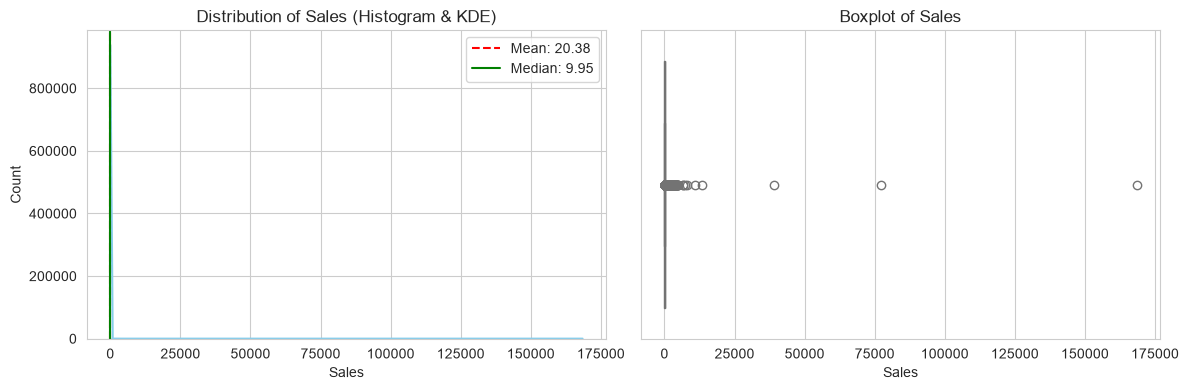

In [15]:
# TODO
# Location
mean_val = df_clean['Sales'].mean()
median_val = df_clean['Sales'].median()
mode_val = df_clean['Sales'].mode()[0]

print(f"Mean: {mean_val:.2f} | Median: {median_val:.2f} | Mode: {mode_val:.2f}")

# Shape
plt.figure(figsize=(12, 4))

# 1. Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Sales'], kde=True, color='skyblue')
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
plt.title('Distribution of Sales (Histogram & KDE)')
plt.legend()

# 2. Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['Sales'], color='lightgreen')
plt.title('Boxplot of Sales')

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [16]:
# TODO
# Gom nhóm theo Country, tính tổng Sales và % tổng
country_sales = df_clean.groupby('Country')['Sales'].sum()
top_country = country_sales.idxmax()
percentage = (country_sales.max() / country_sales.sum()) * 100

print(f"Quốc gia cao nhất: {top_country}")
print(f"Tỷ lệ đóng góp: {percentage:.2f}%")

Quốc gia cao nhất: United Kingdom
Tỷ lệ đóng góp: 84.60%


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [18]:
# TODO
# Gom nhóm theo sản phẩm, sắp xếp giảm dần và lấy TOP 1
top_product = df_clean.groupby(['StockCode', 'Description'])['Sales'].sum().reset_index()
top_product = top_product.sort_values(by='Sales', ascending=False).iloc[0]

print(f"Sản phẩm: {top_product['Description']}")
print(f"Doanh thu: {top_product['Sales']:,.2f}")

Sản phẩm: DOTCOM POSTAGE
Doanh thu: 206,248.77


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

In [ ]:
# Tạo cột Tháng-Năm và gom nhóm tính tổng doanh thu
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('YearMonth')['Sales'].sum()

# In doanh thu các tháng để kết luận
print("Doanh thu theo từng tháng:")
print(monthly_sales)

# In tháng có doanh thu cao nhất và thấp nhất
print(f"\nTháng cao nhất: {monthly_sales.idxmax()} ({monthly_sales.max():,.2f})")
print(f"\nTháng thấp nhất: {monthly_sales.idxmin()} ({monthly_sales.min():,.2f})")


print("--> Doanh thu có tính mùa vụ vì từ tháng 9 trở đi doanh thu tăng rõ rệt do mùa mua sắm Giáng sinh và lễ Tết"

Doanh thu theo từng tháng:
YearMonth
2010-12     812278.130
2011-01     686697.280
2011-02     520741.020
2011-03     713846.910
2011-04     531862.811
2011-05     767540.800
2011-06     756036.500
2011-07     716751.241
2011-08     755784.700
2011-09    1053278.921
2011-10    1143154.260
2011-11    1493710.070
2011-12     635333.090
Freq: M, Name: Sales, dtype: float64

Tháng cao nhất: 2011-11 (1,493,710.07)

Tháng thấp nhất: 2011-02 (520,741.02)


## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [23]:
# TODO
order_val = df_clean.groupby(['Country', 'InvoiceNo'])['Sales'].sum().reset_index()

aov_by_country = order_val.groupby('Country')['Sales'].mean().reset_index()

print("AOV by Country:")
print(aov_by_country)

print("Australia (~2,428.43 USD) và Japan (~1,969.28 USD) dẫn đầu thị trường với giá trị trung bình trên mỗi đơn hàng cao vượt trội.")
print("Bahrain (~251.38 USD), European Community (~325.06 USD), và Unspecified (~361.34 USD) có giá trị đơn hàng trung bình thấp nhất.")

AOV by Country:
                 Country        Sales
0              Australia  2428.431754
1                Austria   599.922353
2                Bahrain   251.380000
3                Belgium   420.370816
4                 Brazil  1143.600000
5                 Canada   611.063333
6        Channel Islands   786.174615
7                 Cyprus   835.678125
8         Czech Republic   413.370000
9                Denmark  1050.782778
10                  EIRE   978.801042
11    European Community   325.062500
12               Finland   544.987317
13                France   534.467245
14               Germany   498.071357
15                Greece   952.104000
16             Hong Kong  1390.527273
17               Iceland   615.714286
18                Israel  1015.657500
19                 Italy   460.085263
20                 Japan  1969.282632
21               Lebanon  1693.880000
22             Lithuania   415.265000
23                 Malta   545.118000
24           Netherlands  3036.663

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [24]:
# TODO

df['Is_Canceled'] = df['Quantity'] < 0


cancel_stats = df.groupby('Country').agg(
    Total_Orders=('Is_Canceled', 'count'),
    Canceled_Orders=('Is_Canceled', 'sum')
)


cancel_stats['Cancel_Rate (%)'] = (cancel_stats['Canceled_Orders'] / cancel_stats['Total_Orders']) * 100
cancel_stats = cancel_stats.sort_values(by='Cancel_Rate (%)', ascending=False)


print("Tỷ lệ hủy/trả hàng theo quốc gia:")
cancel_stats[['Total_Orders', 'Canceled_Orders', 'Cancel_Rate (%)']]

Tỷ lệ hủy/trả hàng theo quốc gia:


,Total_Orders,Canceled_Orders,Cancel_Rate (%)
Country,,,
USA,291,112,38.487973
Czech Republic,30,5,16.666667
Malta,127,15,11.811024
Japan,358,37,10.335196
Saudi Arabia,10,1,10.000000
Australia,1259,74,5.877681
Italy,803,45,5.603985
Bahrain,19,1,5.263158
Germany,9495,453,4.770932


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*


Thị trường trọng điểm & Hành vi mua: United Kingdom đóng góp phần lớn tổng doanh thu nhờ lượng giao dịch nội địa khổng lồ, tuy nhiên giá trị đơn hàng trung bình (AOV) lại ở mức trung bình thấp do nhiều đơn mua lẻ.

Tính mùa vụ (Seasonality): Doanh số tăng trưởng mạnh vào các tháng cuối năm (đặc biệt là Q4), phản ánh rõ nét nhu cầu mua sắm đỉnh điểm vào mùa lễ hội và Giáng sinh.

Rủi ro vận chuyển & Hoàn hủy: Tỷ lệ hủy/trả hàng (Quantity < 0) xuất hiện biến động lớn giữa các quốc gia, trong đó các thị trường quốc tế có AOV cao thường đi kèm rủi ro trả hàng lớn hơn, đòi hỏi doanh nghiệp tối ưu hóa quy trình hậu cần và chính sách CSKH.